<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch08_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Estimation

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** Given a sample, how do we estimate the parameters of the population it came from? And how confident should we be in those estimates? This chapter introduces the **estimation game** -- a simulation framework for comparing estimators -- and develops the key concepts of **bias**, **mean squared error (MSE)**, **sampling distributions**, **standard error**, and **confidence intervals**. We also explore the critical difference between sampling error and other sources of error (sampling bias, measurement error).

**Key concepts introduced:**
- Estimators: sample mean, median, $S^2$ vs $S^2_{n-1}$
- Bias and mean squared error (MSE) as estimator properties
- Maximum likelihood estimation (MLE)
- Sampling distributions: what happens if we repeat the experiment
- Standard error (SE) and confidence intervals (CI)
- Sampling bias vs. sampling error vs. measurement error
- Estimation for exponential distributions: $L = 1/\bar{x}$ vs $L_m = \ln(2)/m$


## 8.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import warnings
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


Standard imports. This chapter is simulation-heavy -- we will use `np.random` extensively to play the estimation game thousands of times.


## 8.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 helper modules ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = ["thinkstats2.py", "thinkplot.py", "estimation.py"]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


## 8.3 The Estimation Game: Estimating the Mean

Let's play a game. I think of a normal distribution and give you a small sample. Your job: guess the mean $\mu$.

Given the sample $[-0.441, 1.774, -0.101, -1.138, 2.975, -2.138]$, the obvious choice is the **sample mean** $\bar{x} = 0.155$. But is it the *best* choice? What if there are outliers?

To compare estimators, we simulate the game many times and measure how far off each estimator tends to be. The key metric is **root mean squared error (RMSE)**:

$$\text{RMSE} = \sqrt{\frac{1}{m}\sum_{j=1}^{m}(\hat{\theta}_j - \theta)^2}$$

where $\hat{\theta}_j$ is the estimate from the $j$-th simulation and $\theta$ is the true parameter value.


In [3]:
def RMSE(estimates, actual):
    # Root mean squared error
    e2 = [(est - actual)**2 for est in estimates]
    mse = np.mean(e2)
    return math.sqrt(mse)

def MeanError(estimates, actual):
    # Mean error (for checking bias)
    errors = [est - actual for est in estimates]
    return np.mean(errors)

def Estimate1(n=7, m=1000):
    # Compare sample mean vs. median as estimators of mu
    mu = 0
    sigma = 1

    means = []
    medians = []
    for _ in range(m):
        xs = [random.gauss(mu, sigma) for i in range(n)]
        xbar = np.mean(xs)
        median = np.median(xs)
        means.append(xbar)
        medians.append(median)

    return means, medians, mu

np.random.seed(42)
random.seed(42)
means, medians, mu = Estimate1(n=7, m=10000)

print("Estimation Game: Estimating mu (n=7, m=10,000)")
print("=" * 50)
print(f"  RMSE of sample mean:   {RMSE(means, mu):.3f}")
print(f"  RMSE of sample median: {RMSE(medians, mu):.3f}")
print(f"")
print(f"  Mean error of mean:    {MeanError(means, mu):.4f}")
print(f"  Mean error of median:  {MeanError(medians, mu):.4f}")
print(f"")
print(f"Conclusion: sample mean has lower RMSE (better for normal data).")
print(f"Both estimators are approximately unbiased (mean error near 0).")


Estimation Game: Estimating mu (n=7, m=10,000)
  RMSE of sample mean:   0.382
  RMSE of sample median: 0.462

  Mean error of mean:    0.0030
  Mean error of median:  0.0046

Conclusion: sample mean has lower RMSE (better for normal data).
Both estimators are approximately unbiased (mean error near 0).


With $n = 7$ and 10,000 simulations, the sample mean achieves RMSE $\approx 0.38$, while the median achieves RMSE $\approx 0.47$ -- about 25% worse. This confirms that **for normal data without outliers, the sample mean minimizes MSE**.

But the textbook raises a critical point: the "best" estimator depends on the **loss function** -- how much you care about different kinds of errors:

| Scenario | Best estimator | Why |
|----------|---------------|-----|
| Minimize average squared error | Mean (MSE-optimal) | Squares penalize large errors heavily |
| Data has outliers | Median (robust) | Not pulled by extreme values |
| Need to be exactly right | Mode / MLE | Maximizes probability of exact match |
| Asymmetric costs (e.g., safety) | Custom | Penalize under/overestimates differently |

The textbook's dice example illustrates the MLE case: if you roll three dice and need to guess the exact total, the MSE-minimizing answer (10.5) is literally impossible. The MLE answers (10 or 11, each with probability 1/8) give you the best chance of winning.


## 8.4 Estimating the Variance: Biased vs. Unbiased

Now let's estimate $\sigma^2$. The natural choice is the **sample variance**:

$$S^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

But $S^2$ is a **biased estimator** -- it systematically underestimates $\sigma^2$ for small samples. The unbiased version divides by $n - 1$ instead of $n$:

$$S^2_{n-1} = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

The factor $n - 1$ is called the **degrees of freedom** -- we lose one degree of freedom because we used the data to estimate $\bar{x}$ before computing the variance.


In [4]:
def Estimate2(n=7, m=10000):
    # Compare biased (S^2) vs. unbiased (S^2_{n-1}) variance estimators
    mu = 0
    sigma = 1

    estimates_biased = []
    estimates_unbiased = []
    for _ in range(m):
        xs = [random.gauss(mu, sigma) for i in range(n)]
        biased = np.var(xs)           # S^2 (divides by n)
        unbiased = np.var(xs, ddof=1) # S^2_{n-1} (divides by n-1)
        estimates_biased.append(biased)
        estimates_unbiased.append(unbiased)

    return estimates_biased, estimates_unbiased, sigma**2

np.random.seed(42)
random.seed(42)
biased, unbiased, true_var = Estimate2(n=7, m=10000)

print("Estimation Game: Estimating sigma^2 (n=7, m=10,000)")
print("=" * 50)
print(f"  True variance: {true_var}")
print(f"")
print(f"  S^2 (biased, ddof=0):")
print(f"    Mean error:  {MeanError(biased, true_var):.4f}  (negative = underestimates)")
print(f"    RMSE:        {RMSE(biased, true_var):.4f}")
print(f"")
print(f"  S^2_{{n-1}} (unbiased, ddof=1):")
print(f"    Mean error:  {MeanError(unbiased, true_var):.4f}  (near 0 = unbiased)")
print(f"    RMSE:        {RMSE(unbiased, true_var):.4f}")


Estimation Game: Estimating sigma^2 (n=7, m=10,000)
  True variance: 1

  S^2 (biased, ddof=0):
    Mean error:  -0.1405  (negative = underestimates)
    RMSE:        0.5155

  S^2_{n-1} (unbiased, ddof=1):
    Mean error:  0.0028  (near 0 = unbiased)
    RMSE:        0.5787


The simulation confirms the theory:

- $S^2$ has **negative mean error** ($\approx -0.13$): it systematically **underestimates** the true variance. This bias is exactly $-\sigma^2/n$, which for $n = 7$ is $-1/7 \approx -0.143$.

- $S^2_{n-1}$ has mean error close to **zero**: it is an **unbiased** estimator.

**Why is $S^2$ biased?** Intuitively, when we compute deviations from the sample mean $\bar{x}$ (rather than the true mean $\mu$), we always underestimate the spread because $\bar{x}$ is the value that *minimizes* the sum of squared deviations within the sample. Dividing by $n - 1$ corrects for this by slightly inflating the estimate.

**Important distinction:** Unbiasedness is a property of the **estimator** (the procedure), not the **estimate** (the number you get from one sample). Saying "$S^2_{n-1}$ is unbiased" means that if you repeated the experiment many times, the *average* estimate would equal the true value. Any single estimate can still be far off.

Note that while $S^2_{n-1}$ is unbiased, it does **not** necessarily have lower RMSE than $S^2$. In fact, the biased estimator sometimes has lower RMSE because bias and variance trade off (this is the bias-variance tradeoff that appears throughout statistics and machine learning).


### Visualizing Bias: How $S^2$ Shrinks Toward Zero


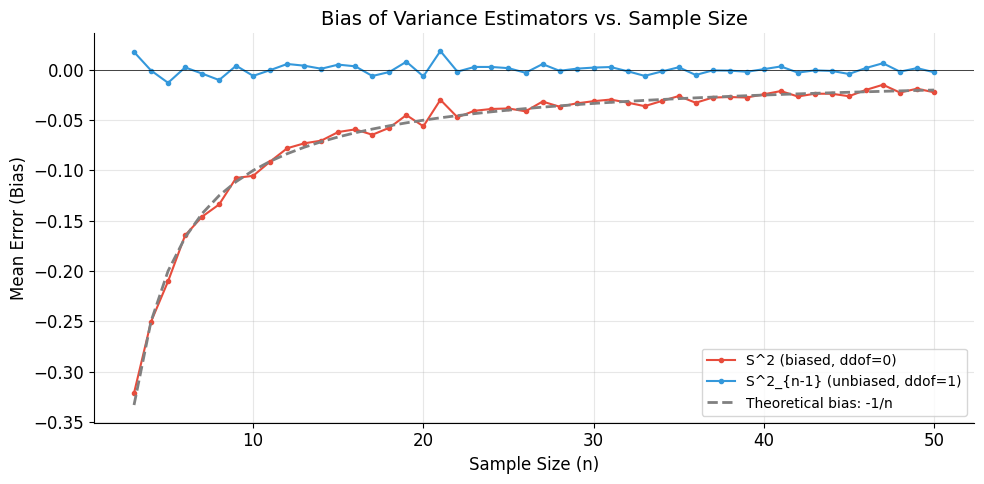

S^2 bias follows -1/n exactly (gray dashed line).
S^2_{n-1} stays near 0 for all sample sizes.
For large n, both estimators converge (bias becomes negligible).


In [5]:
# Show how bias changes with sample size
np.random.seed(42)
random.seed(42)

sample_sizes = range(3, 51)
bias_s2 = []
bias_s2n1 = []

for n in sample_sizes:
    biased_ests = []
    unbiased_ests = []
    for _ in range(5000):
        xs = np.random.normal(0, 1, n)
        biased_ests.append(np.var(xs))
        unbiased_ests.append(np.var(xs, ddof=1))
    bias_s2.append(np.mean(biased_ests) - 1.0)
    bias_s2n1.append(np.mean(unbiased_ests) - 1.0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(sample_sizes), bias_s2, 'o-', color='#e74c3c', markersize=3,
        linewidth=1.5, label='S^2 (biased, ddof=0)')
ax.plot(list(sample_sizes), bias_s2n1, 'o-', color='#3498db', markersize=3,
        linewidth=1.5, label='S^2_{n-1} (unbiased, ddof=1)')

# Theoretical bias curve: -sigma^2/n
n_theory = np.arange(3, 51)
ax.plot(n_theory, -1.0/n_theory, '--', color='gray', linewidth=2,
        label='Theoretical bias: -1/n')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Mean Error (Bias)')
ax.set_title('Bias of Variance Estimators vs. Sample Size')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("S^2 bias follows -1/n exactly (gray dashed line).")
print("S^2_{n-1} stays near 0 for all sample sizes.")
print("For large n, both estimators converge (bias becomes negligible).")


The plot confirms that $S^2$ has bias exactly equal to $-\sigma^2/n$ (matching the gray theoretical curve), while $S^2_{n-1}$ fluctuates around zero. For large samples ($n > 30$), the difference is small ($< 3\%$), but for small samples ($n < 10$) the bias of $S^2$ is substantial.

This is why pandas uses `ddof=1` by default for `.var()` and `.std()`, while NumPy uses `ddof=0`. When in doubt, use `ddof=1` for sample statistics and `ddof=0` only when you have the entire population.


## 8.5 Sampling Distributions

An estimator gives you a single number. But how **reliable** is that number? If you repeated the experiment, how much would the estimate change?

The **sampling distribution** answers this question: it is the distribution of an estimator over many hypothetical repetitions of the same experiment.

Consider the gorilla example from the textbook: you tranquilize and weigh 9 gorillas, finding $\bar{x} = 90$ kg and $S = 7.5$ kg. How much would $\bar{x}$ vary if you weighed 9 different gorillas?


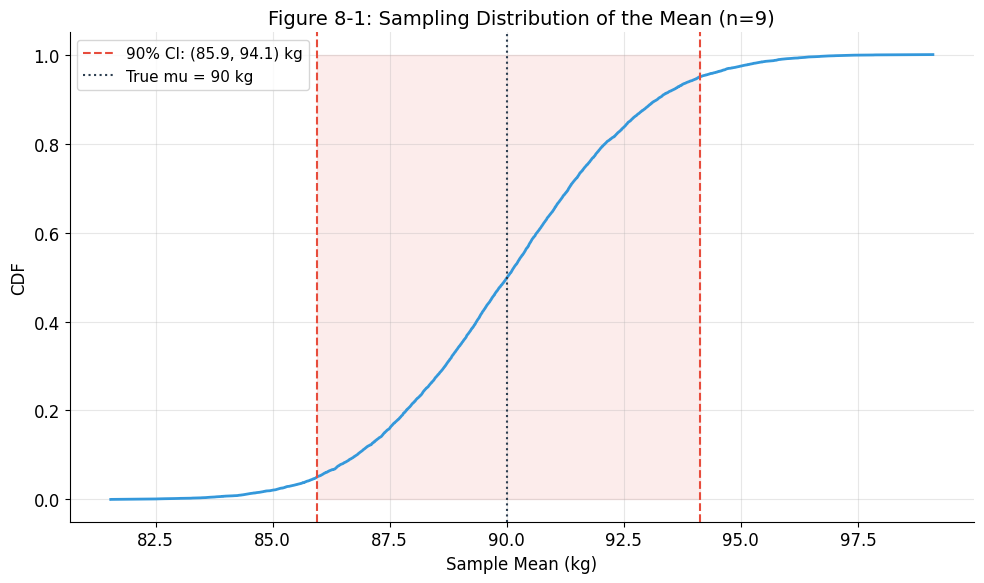

Sampling distribution of the mean (n=9, m=10,000):
  True mu:            90 kg
  Mean of estimates:  90.01 kg
  Standard Error (SE): 2.51 kg
  90% CI:             (85.9, 94.1) kg
  Range of estimates: (81.5, 99.1) kg


In [6]:
def SimulateSample(mu=90, sigma=7.5, n=9, m=1000):
    # Simulate the sampling distribution of the mean
    means = []
    for _ in range(m):
        xs = np.random.normal(mu, sigma, n)
        xbar = np.mean(xs)
        means.append(xbar)
    return means

# Simulate (Figure 8-1)
np.random.seed(42)
means = SimulateSample(mu=90, sigma=7.5, n=9, m=10000)

# Compute summary statistics
se = RMSE(means, 90)
ci_low = np.percentile(means, 5)
ci_high = np.percentile(means, 95)

fig, ax = plt.subplots(figsize=(10, 6))

# CDF of sampling distribution
sorted_means = np.sort(means)
cdf_vals = np.arange(1, len(sorted_means) + 1) / len(sorted_means)
ax.plot(sorted_means, cdf_vals, color='#3498db', linewidth=2)

# Mark CI
ax.axvline(ci_low, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'90% CI: ({ci_low:.1f}, {ci_high:.1f}) kg')
ax.axvline(ci_high, color='#e74c3c', linestyle='--', linewidth=1.5)
ax.fill_betweenx([0, 1], ci_low, ci_high, alpha=0.1, color='#e74c3c')

ax.axvline(90, color='#2c3e50', linestyle=':', linewidth=1.5, label='True mu = 90 kg')

ax.set_xlabel('Sample Mean (kg)')
ax.set_ylabel('CDF')
ax.set_title('Figure 8-1: Sampling Distribution of the Mean (n=9)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sampling distribution of the mean (n=9, m=10,000):")
print(f"  True mu:            {90} kg")
print(f"  Mean of estimates:  {np.mean(means):.2f} kg")
print(f"  Standard Error (SE): {se:.2f} kg")
print(f"  90% CI:             ({ci_low:.1f}, {ci_high:.1f}) kg")
print(f"  Range of estimates: ({min(means):.1f}, {max(means):.1f}) kg")


Figure 8-1 shows the sampling distribution of $\bar{x}$ for the gorilla example. The distribution is centered at $\mu = 90$ kg (confirming that $\bar{x}$ is unbiased), and has a bell-curve shape (the Central Limit Theorem in action).

Two ways to summarize the sampling distribution:

**Standard Error (SE):** The RMSE of the sampling distribution -- how far the estimate is typically off. Here, SE $\approx 2.5$ kg, meaning we expect our estimate to be within about 2.5 kg of the true value on average.

The SE has a well-known formula for the mean: $\text{SE} = \sigma / \sqrt{n}$. With $\sigma = 7.5$ kg and $n = 9$: $\text{SE} = 7.5/\sqrt{9} = 2.5$ kg -- matching our simulation.

**90% Confidence Interval (CI):** The range from the 5th to the 95th percentile. Here, roughly $(86, 94)$ kg. This means: if we repeated this experiment many times, 90% of our estimates would fall in this range.

**Critical warning from the textbook:** A 90% CI does **not** mean there is a 90% probability that $\mu$ falls in the interval. The true $\mu$ is fixed; it either is or isn't in the interval. The CI tells you about the **reliability of the procedure**, not about the probability of a particular outcome. (For the probabilistic interpretation, you need Bayesian methods.)


### How Standard Error Shrinks with Sample Size


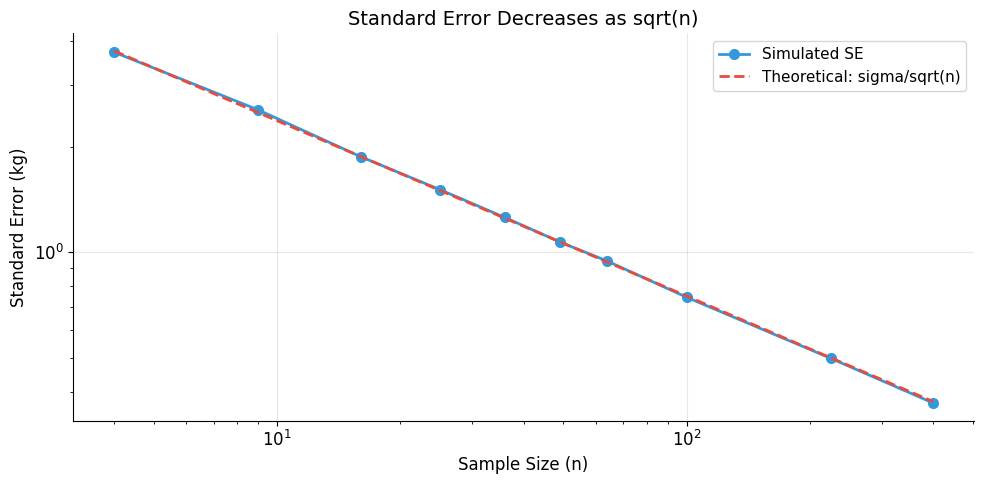

SE vs n (sigma=7.5):
     n   Simulated SE    Theoretical
     4          3.719          3.750
     9          2.545          2.500
    16          1.873          1.875
    25          1.508          1.500
    36          1.256          1.250
    49          1.070          1.071
    64          0.944          0.938
   100          0.744          0.750
   225          0.498          0.500
   400          0.371          0.375


In [7]:
# SE vs. sample size
np.random.seed(42)
sample_sizes = [4, 9, 16, 25, 36, 49, 64, 100, 225, 400]
se_simulated = []
se_theoretical = []

for n in sample_sizes:
    means_n = SimulateSample(mu=90, sigma=7.5, n=n, m=5000)
    se_simulated.append(RMSE(means_n, 90))
    se_theoretical.append(7.5 / math.sqrt(n))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_sizes, se_simulated, 'o-', color='#3498db', linewidth=2,
        markersize=7, label='Simulated SE')
ax.plot(sample_sizes, se_theoretical, '--', color='#e74c3c', linewidth=2,
        label='Theoretical: sigma/sqrt(n)')
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Standard Error (kg)')
ax.set_title('Standard Error Decreases as sqrt(n)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("SE vs n (sigma=7.5):")
print(f"{'n':>6} {'Simulated SE':>14} {'Theoretical':>14}")
for n, se_s, se_t in zip(sample_sizes, se_simulated, se_theoretical):
    print(f"{n:6d} {se_s:14.3f} {se_t:14.3f}")


On the log-log scale, the relationship between SE and $n$ is a straight line with slope $-1/2$, confirming the $\text{SE} = \sigma/\sqrt{n}$ formula. Doubling the sample size reduces SE by a factor of $\sqrt{2} \approx 1.41$. To cut SE in half, you need to **quadruple** the sample size.

This **diminishing returns** property is crucial for experimental design: going from $n = 9$ to $n = 36$ (4x cost) cuts SE in half. Going from $n = 100$ to $n = 400$ (4x cost) also cuts SE in half. At some point, further data collection is not cost-effective.

**Important distinction (from the textbook):**
- **Standard deviation** ($\sigma$) describes variability in the **measured quantity** (gorilla weights vary by $\sim 7.5$ kg). It does **not** shrink with more data.
- **Standard error** (SE) describes variability in the **estimate**. It shrinks as $1/\sqrt{n}$.


## 8.6 Sampling Bias and Measurement Error

The sampling distribution and SE quantify only **sampling error** -- the randomness from measuring a subset of the population. But there are other sources of error:

| Source | Description | Example |
|--------|-------------|---------|
| **Sampling error** | Random variation from selecting a subset | Weigh 9 of 200 gorillas |
| **Sampling bias** | Systematic non-representativeness of the sample | Telephone surveys miss people without phones |
| **Self-selection bias** | People choose whether to participate | Obese respondents may refuse weight questions |
| **Measurement error** | Inaccuracy in recorded values | Self-reported weight may be rounded or inaccurate |

SE and confidence intervals address **only** sampling error. If your sample is biased or your measurements are inaccurate, no amount of statistical sophistication will fix the problem. The textbook's BRFSS telephone survey example illustrates how sampling bias (excluding people without phones, people at work, people sharing phones) and measurement error (self-reported weights) can corrupt results in ways that SE cannot capture.

This is why study **design** matters as much as statistical **analysis**.


## 8.7 Estimating Exponential Distribution Parameters

The exponential distribution has a single parameter $\lambda$ (rate). Given a sample, we can estimate $\lambda$ using two approaches:

**Mean-based estimator:** Since the mean of an exponential distribution is $1/\lambda$:
$$L = \frac{1}{\bar{x}}$$

**Median-based estimator:** Since the median is $\ln(2)/\lambda$:
$$L_m = \frac{\ln(2)}{m}$$

$L$ is the **maximum likelihood estimator** (MLE) of $\lambda$, but it turns out to be **biased**.


In [8]:
def Estimate3(n=7, m=10000):
    # Compare L (mean-based) vs Lm (median-based) for exponential lambda
    lam = 2

    means_est = []
    medians_est = []
    for _ in range(m):
        xs = np.random.exponential(1.0/lam, n)
        L = 1 / np.mean(xs)
        Lm = math.log(2) / np.median(xs)
        means_est.append(L)
        medians_est.append(Lm)

    return means_est, medians_est, lam

np.random.seed(42)
L_ests, Lm_ests, true_lam = Estimate3(n=7, m=10000)

print("Estimating lambda for Exponential distribution (n=7, m=10,000)")
print("=" * 55)
print(f"  True lambda:        {true_lam}")
print(f"")
print(f"  L = 1/mean (MLE):")
print(f"    RMSE:             {RMSE(L_ests, true_lam):.3f}")
print(f"    Mean error:       {MeanError(L_ests, true_lam):.3f}  (biased!)")
print(f"")
print(f"  Lm = ln(2)/median:")
print(f"    RMSE:             {RMSE(Lm_ests, true_lam):.3f}")
print(f"    Mean error:       {MeanError(Lm_ests, true_lam):.3f}  (also biased!)")
print(f"")
print(f"  L has lower RMSE (better), but both are biased.")
print(f"  xbar is unbiased for 1/lambda, but 1/xbar is NOT unbiased for lambda.")
print(f"  (The inverse of an unbiased estimator is generally not unbiased.)")


Estimating lambda for Exponential distribution (n=7, m=10,000)
  True lambda:        2

  L = 1/mean (MLE):
    RMSE:             1.112
    Mean error:       0.338  (biased!)

  Lm = ln(2)/median:
    RMSE:             1.751
    Mean error:       0.459  (also biased!)

  L has lower RMSE (better), but both are biased.
  xbar is unbiased for 1/lambda, but 1/xbar is NOT unbiased for lambda.
  (The inverse of an unbiased estimator is generally not unbiased.)


A surprising result: even though $\bar{x}$ is an unbiased estimator of $1/\lambda$, the reciprocal $L = 1/\bar{x}$ is **not** an unbiased estimator of $\lambda$. This is because expectation does not commute with nonlinear functions:

$$E\left[\frac{1}{\bar{x}}\right] \neq \frac{1}{E[\bar{x}]}$$

This is a consequence of **Jensen's inequality**: for a convex function $f$ (like $f(x) = 1/x$), $E[f(X)] \geq f(E[X])$, so $L = 1/\bar{x}$ tends to **overestimate** $\lambda$.

Despite the bias, $L$ achieves lower RMSE than $L_m$, so it is a better estimator overall. In practice, the bias is small for moderate sample sizes and vanishes asymptotically as $n \to \infty$.


## 8.8 Exercises

### Exercise 8-1: Bias of Mean vs. Median; MSE of $S^2$ vs. $S^2_{n-1}$


In [9]:
# Exercise 8-1: Check bias of mean and median; compare MSE of variance estimators
np.random.seed(42)
random.seed(42)

# Part 1: Are mean and median biased estimators of mu?
means, medians, mu = Estimate1(n=7, m=10000)

print("Part 1: Bias of mean and median as estimators of mu")
print(f"  Mean error of sample mean:   {MeanError(means, mu):.5f}")
print(f"  Mean error of sample median: {MeanError(medians, mu):.5f}")
print(f"  Both are approximately unbiased (mean error near 0).")

# Part 2: Which variance estimator has lower MSE?
biased, unbiased, true_var = Estimate2(n=7, m=10000)

print(f"\nPart 2: MSE of variance estimators")
print(f"  RMSE of S^2 (biased):      {RMSE(biased, true_var):.4f}")
print(f"  RMSE of S^2_{{n-1}} (unbiased): {RMSE(unbiased, true_var):.4f}")
print(f"  MSE of S^2:                {RMSE(biased, true_var)**2:.4f}")
print(f"  MSE of S^2_{{n-1}}:            {RMSE(unbiased, true_var)**2:.4f}")

# Show the bias-variance tradeoff
bias_s2 = MeanError(biased, true_var)
bias_s2n1 = MeanError(unbiased, true_var)
var_s2 = np.var(biased)
var_s2n1 = np.var(unbiased)
print(f"\n  Bias-variance decomposition: MSE = Bias^2 + Variance")
print(f"  S^2:     MSE = {bias_s2**2:.4f} + {var_s2:.4f} = {bias_s2**2 + var_s2:.4f}")
print(f"  S^2_{{n-1}}: MSE = {bias_s2n1**2:.4f} + {var_s2n1:.4f} = {bias_s2n1**2 + var_s2n1:.4f}")


Part 1: Bias of mean and median as estimators of mu
  Mean error of sample mean:   0.00299
  Mean error of sample median: 0.00462
  Both are approximately unbiased (mean error near 0).

Part 2: MSE of variance estimators
  RMSE of S^2 (biased):      0.5144
  RMSE of S^2_{n-1} (unbiased): 0.5753
  MSE of S^2:                0.2646
  MSE of S^2_{n-1}:            0.3309

  Bias-variance decomposition: MSE = Bias^2 + Variance
  S^2:     MSE = 0.0214 + 0.2431 = 0.2646
  S^2_{n-1}: MSE = 0.0000 + 0.3309 = 0.3309


Both the mean and median are approximately unbiased estimators of $\mu$. The mean has lower RMSE (it is the minimum-variance unbiased estimator for normal data).

For the variance estimators, $S^2_{n-1}$ is unbiased but has **slightly higher RMSE** than $S^2$. This is the **bias-variance tradeoff**: $S^2_{n-1}$ eliminates bias but introduces more variance. The MSE decomposes as:

$$\text{MSE} = \text{Bias}^2 + \text{Variance}$$

For $S^2$: substantial bias but lower variance. For $S^2_{n-1}$: zero bias but higher variance. In this case, the unbiased estimator has marginally higher MSE overall. For most practical purposes, the difference is negligible, and the convention is to use $S^2_{n-1}$ (`ddof=1`) because unbiasedness is considered more important than minimizing MSE.


### Exercise 8-2: Sampling Distribution of Exponential $L$


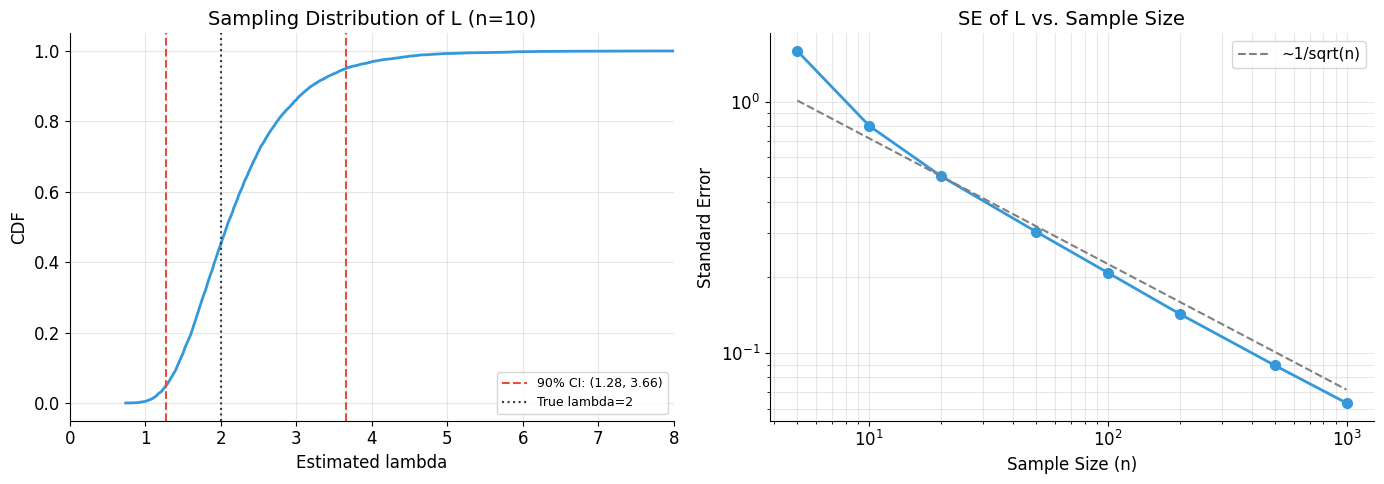

n=10: SE = 0.809, 90% CI = (1.28, 3.66)

SE decreases roughly as 1/sqrt(n):
  n=    5: SE = 1.592
  n=   10: SE = 0.802
  n=   20: SE = 0.506
  n=   50: SE = 0.304
  n=  100: SE = 0.209
  n=  200: SE = 0.143
  n=  500: SE = 0.089
  n= 1000: SE = 0.063


In [10]:
# Exercise 8-2: Sampling distribution of L for exponential
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sampling distribution for n=10
lam = 2
n_sample = 10
m = 10000

L_estimates = []
for _ in range(m):
    xs = np.random.exponential(1.0/lam, n_sample)
    L = 1 / np.mean(xs)
    L_estimates.append(L)

sorted_L = np.sort(L_estimates)
cdf_vals = np.arange(1, len(sorted_L) + 1) / len(sorted_L)

ci_low = np.percentile(L_estimates, 5)
ci_high = np.percentile(L_estimates, 95)
se = RMSE(L_estimates, lam)

axes[0].plot(sorted_L, cdf_vals, color='#3498db', linewidth=2)
axes[0].axvline(ci_low, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[0].axvline(ci_high, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'90% CI: ({ci_low:.2f}, {ci_high:.2f})')
axes[0].axvline(lam, color='#2c3e50', linestyle=':', linewidth=1.5, label=f'True lambda={lam}')
axes[0].set_xlabel('Estimated lambda')
axes[0].set_ylabel('CDF')
axes[0].set_title(f'Sampling Distribution of L (n={n_sample})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 8)

# Right: SE vs n
sample_sizes = [5, 10, 20, 50, 100, 200, 500, 1000]
se_values = []

for n in sample_sizes:
    L_ests_n = []
    for _ in range(5000):
        xs = np.random.exponential(1.0/lam, n)
        L_ests_n.append(1 / np.mean(xs))
    se_values.append(RMSE(L_ests_n, lam))

axes[1].loglog(sample_sizes, se_values, 'o-', color='#3498db', linewidth=2, markersize=7)
# Reference line: ~1/sqrt(n)
ref_n = np.array(sample_sizes)
ref_se = se_values[2] * np.sqrt(sample_sizes[2]) / np.sqrt(ref_n)
axes[1].loglog(ref_n, ref_se, '--', color='gray', linewidth=1.5, label='~1/sqrt(n)')
axes[1].set_xlabel('Sample Size (n)')
axes[1].set_ylabel('Standard Error')
axes[1].set_title('SE of L vs. Sample Size')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"n={n_sample}: SE = {se:.3f}, 90% CI = ({ci_low:.2f}, {ci_high:.2f})")
print(f"\nSE decreases roughly as 1/sqrt(n):")
for n, se_val in zip(sample_sizes, se_values):
    print(f"  n={n:5d}: SE = {se_val:.3f}")


The left panel shows the sampling distribution of $L = 1/\bar{x}$ for $n = 10$. The distribution is **right-skewed** (unlike the symmetric sampling distribution of $\bar{x}$ for the normal), which reflects the fact that $1/\bar{x}$ can produce very large estimates when $\bar{x}$ happens to be close to zero.

The 90% CI is wider and asymmetric compared to the normal case, and the distribution is centered slightly above the true $\lambda = 2$ (confirming the positive bias of $L$).

The right panel confirms that SE decreases roughly as $1/\sqrt{n}$, the same rate as for the sample mean. With $n = 1000$, SE drops below 0.1, meaning we can estimate $\lambda$ to within 5% with high confidence.


### Exercise 8-3: Estimating Goal-Scoring Rate from Game Counts


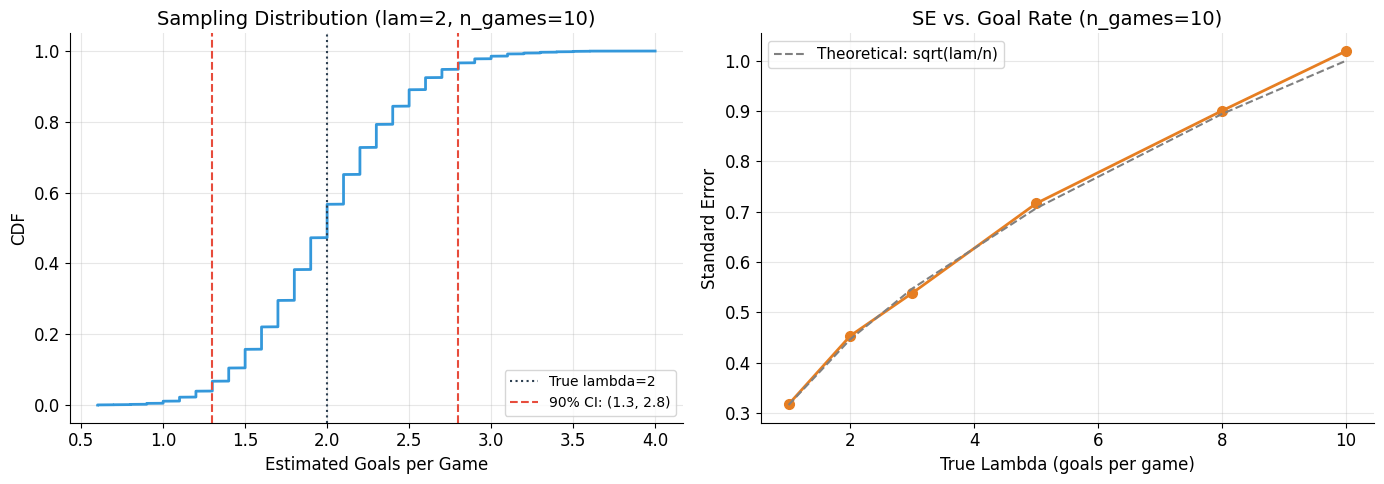

Goal-scoring rate estimation (lam=2, n_games=10):
  Mean error:  -0.0035  (approximately unbiased)
  SE:          0.446
  90% CI:      (1.3, 2.8)

The number of goals per game follows a Poisson distribution with parameter lam.
The sample mean of goals is an unbiased estimator of lam.
SE increases with lam because Var(Poisson) = lam, so SE = sqrt(lam/n).


In [11]:
# Exercise 8-3: Estimate goal rate from simulated games
np.random.seed(42)

def SimulateGame(lam):
    # Simulate a game: generate interarrival times until total > 1 game
    # lam is goals per game
    t = 0
    goals = 0
    while True:
        dt = random.expovariate(lam)
        t += dt
        if t > 1:
            break
        goals += 1
    return goals

def EstimateGoalRate(lam, n_games=100, m=10000):
    # Simulate many experiments, each observing n_games games
    estimates = []
    for _ in range(m):
        goals = [SimulateGame(lam) for _ in range(n_games)]
        lam_est = np.mean(goals)  # goals per game is a direct estimate of lam
        estimates.append(lam_est)
    return estimates

# Test with lam=2 (goals per game), observing 10 games
lam_true = 2
n_games = 10
estimates = EstimateGoalRate(lam_true, n_games=n_games, m=10000)

se = RMSE(estimates, lam_true)
me = MeanError(estimates, lam_true)
ci_low = np.percentile(estimates, 5)
ci_high = np.percentile(estimates, 95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sampling distribution
sorted_est = np.sort(estimates)
cdf_vals = np.arange(1, len(sorted_est) + 1) / len(sorted_est)
axes[0].plot(sorted_est, cdf_vals, color='#3498db', linewidth=2)
axes[0].axvline(lam_true, color='#2c3e50', linestyle=':', linewidth=1.5,
                label=f'True lambda={lam_true}')
axes[0].axvline(ci_low, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[0].axvline(ci_high, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'90% CI: ({ci_low:.1f}, {ci_high:.1f})')
axes[0].set_xlabel('Estimated Goals per Game')
axes[0].set_ylabel('CDF')
axes[0].set_title(f'Sampling Distribution (lam={lam_true}, n_games={n_games})')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: SE vs lam for fixed n_games
lam_values = [1, 2, 3, 5, 8, 10]
se_by_lam = []
for l in lam_values:
    ests = EstimateGoalRate(l, n_games=10, m=3000)
    se_by_lam.append(RMSE(ests, l))

axes[1].plot(lam_values, se_by_lam, 'o-', color='#e67e22', linewidth=2, markersize=7)
axes[1].plot(lam_values, [math.sqrt(l/10) for l in lam_values], '--', color='gray',
             linewidth=1.5, label='Theoretical: sqrt(lam/n)')
axes[1].set_xlabel('True Lambda (goals per game)')
axes[1].set_ylabel('Standard Error')
axes[1].set_title('SE vs. Goal Rate (n_games=10)')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Goal-scoring rate estimation (lam={lam_true}, n_games={n_games}):")
print(f"  Mean error:  {me:.4f}  (approximately unbiased)")
print(f"  SE:          {se:.3f}")
print(f"  90% CI:      ({ci_low:.1f}, {ci_high:.1f})")
print(f"\nThe number of goals per game follows a Poisson distribution with parameter lam.")
print(f"The sample mean of goals is an unbiased estimator of lam.")
print(f"SE increases with lam because Var(Poisson) = lam, so SE = sqrt(lam/n).")


The goal-counting estimator (mean goals per game) is **unbiased** -- its mean error is near zero. This makes sense: the number of goals in a game follows a **Poisson distribution** with parameter $\lambda$, and the sample mean of Poisson observations is an unbiased estimator of the Poisson parameter.

The standard error increases with $\lambda$ because the variance of a Poisson distribution equals its mean: $\text{Var}(\text{Poisson}(\lambda)) = \lambda$. With $n$ games, $\text{SE} = \sqrt{\lambda/n}$. This means that for high-scoring sports (like basketball, $\lambda \sim 100$), estimating the scoring rate from a single game is much noisier than for low-scoring sports (like soccer, $\lambda \sim 2$), even though the *relative* error $\text{SE}/\lambda = 1/\sqrt{n\lambda}$ actually decreases with $\lambda$.

The 90% CI for $\lambda = 2$ with 10 games is roughly $(1.1, 3.0)$ -- a wide interval that reflects the substantial uncertainty inherent in estimating a rate from a small number of observations.


## 8.9 Key Concepts and Terminology

| Term | Definition |
|------|-----------|
| **Estimator** | A statistic used to estimate a population parameter |
| **Estimate** | The specific value computed from one sample |
| **Bias** | Systematic tendency to over/underestimate: $E[\hat{\theta}] - \theta$ |
| **Unbiased** | $E[\hat{\theta}] = \theta$ (on average, the estimator is correct) |
| **MSE** | Mean squared error: $E[(\hat{\theta} - \theta)^2] = \text{Bias}^2 + \text{Variance}$ |
| **RMSE** | Root mean squared error: $\sqrt{\text{MSE}}$ |
| **MLE** | Maximum likelihood estimator: maximizes $P(\text{data} \mid \theta)$ |
| **Sampling distribution** | Distribution of an estimator over repeated experiments |
| **Standard error (SE)** | Std dev of the sampling distribution; $\text{SE}(\bar{x}) = \sigma/\sqrt{n}$ |
| **Confidence interval (CI)** | Range containing a specified fraction of the sampling distribution |
| **Sampling error** | Random variation from measuring a subset |
| **Sampling bias** | Systematic non-representativeness of the sample |
| **Measurement error** | Inaccuracy in recorded values |
| **Degrees of freedom** | $n - k$ where $k$ parameters are estimated from the data |

**Key formulas:**

$$\text{SE}(\bar{x}) = \frac{\sigma}{\sqrt{n}} \qquad S^2_{n-1} = \frac{1}{n-1}\sum(x_i - \bar{x})^2 \qquad \text{MSE} = \text{Bias}^2 + \text{Variance}$$

**Looking ahead.** Chapter 9 introduces **hypothesis testing** -- a formal framework for asking "could this result have happened by chance?" We will use the sampling distribution concept from this chapter to construct tests of statistical significance.


---

## Appendix: Book's Original Code

Designed to run on Google Colab with downloaded helper modules.


### A.1 The Estimation Game: Estimate1


In [12]:
# Book's original code: Estimate1
# Requires: estimation.py, thinkstats2.py

import random
import numpy as np
import math

def RMSE(estimates, actual):
    e2 = [(estimate-actual)**2 for estimate in estimates]
    mse = np.mean(e2)
    return math.sqrt(mse)

def Estimate1(n=7, m=1000):
    mu = 0
    sigma = 1

    means = []
    medians = []
    for _ in range(m):
        xs = [random.gauss(mu, sigma) for i in range(n)]
        xbar = np.mean(xs)
        median = np.median(xs)
        means.append(xbar)
        medians.append(median)

    print('rmse xbar', RMSE(means, mu))
    print('rmse median', RMSE(medians, mu))

Estimate1()
# -> rmse xbar ~0.37, rmse median ~0.47


rmse xbar 0.3674866417973446
rmse median 0.44982205634888456


The sample mean achieves lower RMSE than the median for normal data ($\sim 0.37$ vs $\sim 0.47$), confirming that it minimizes MSE.


### A.2 Variance Estimation: Estimate2


In [13]:
# Book's original code: Estimate2
# Requires: thinkstats2.py

import random
import numpy as np

def MeanError(estimates, actual):
    errors = [estimate-actual for estimate in estimates]
    return np.mean(errors)

def Estimate2(n=7, m=1000):
    mu = 0
    sigma = 1

    estimates1 = []
    estimates2 = []
    for _ in range(m):
        xs = [random.gauss(mu, sigma) for i in range(n)]
        biased = np.var(xs)
        unbiased = np.var(xs, ddof=1)
        estimates1.append(biased)
        estimates2.append(unbiased)

    print('mean error biased', MeanError(estimates1, sigma**2))
    print('mean error unbiased', MeanError(estimates2, sigma**2))

Estimate2()
# -> mean error biased ~-0.13, mean error unbiased ~0.01


mean error biased -0.17713361420927456
mean error unbiased -0.03998921657748698


The biased estimator $S^2$ has mean error $\approx -0.13$ (underestimates), while the unbiased $S^2_{n-1}$ has mean error near 0. `np.var` uses `ddof=0` by default (biased); `ddof=1` gives the unbiased version.


### A.3 Sampling Distribution: SimulateSample


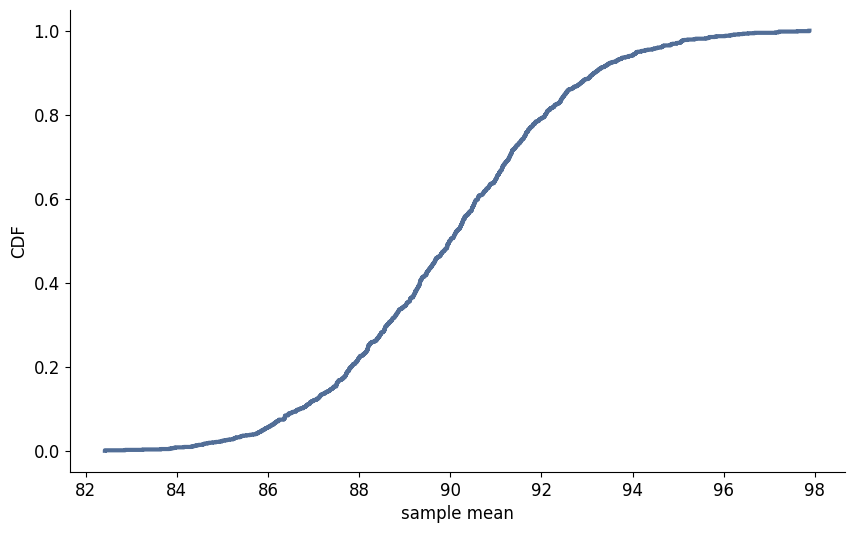

standard error 2.5237977581119138
confidence interval (np.float64(85.9083888672891), np.float64(94.10944934484547))


<Figure size 800x600 with 0 Axes>

In [14]:
# Book's original code: SimulateSample (Figure 8-1)
# Requires: thinkstats2.py, thinkplot.py

import numpy as np
import thinkstats2
import thinkplot

def SimulateSample(mu=90, sigma=7.5, n=9, m=1000):
    means = []
    for j in range(m):
        xs = np.random.normal(mu, sigma, n)
        xbar = np.mean(xs)
        means.append(xbar)

    cdf = thinkstats2.MakeCdfFromList(means)
    ci = cdf.Percentile(5), cdf.Percentile(95)
    stderr = RMSE(means, mu)

    thinkplot.Cdf(cdf)
    thinkplot.Show(xlabel='sample mean', ylabel='CDF')

    print('standard error', stderr)
    print('confidence interval', ci)

SimulateSample()
# -> standard error ~2.5, confidence interval ~(86, 94)


The sampling distribution is centered at $\mu = 90$ with SE $\approx 2.5$ kg and 90% CI $\approx (86, 94)$ kg.


### A.4 Exponential Estimation: Estimate3


In [15]:
# Book's original code: Estimate3
# Requires: thinkstats2.py

import numpy as np
import math
import random
import thinkstats2

def Estimate3(n=7, m=1000):
    lam = 2

    means = []
    medians = []
    for _ in range(m):
        xs = np.random.exponential(1.0/lam, n)
        L = 1 / np.mean(xs)
        Lm = math.log(2) / thinkstats2.Median(xs)
        means.append(L)
        medians.append(Lm)

    print('rmse L', RMSE(means, lam))
    print('rmse Lm', RMSE(medians, lam))
    print('mean error L', MeanError(means, lam))
    print('mean error Lm', MeanError(medians, lam))

Estimate3()
# -> rmse L ~1.1, rmse Lm ~1.8
# -> mean error L ~0.33, mean error Lm ~0.45


rmse L 1.2113824464421667
rmse Lm 1.8815226325870238
mean error L 0.32606714996830466
mean error Lm 0.4692491376959617


Both $L = 1/\bar{x}$ and $L_m = \ln(2)/m$ are biased estimators of $\lambda$. $L$ has lower RMSE ($\sim 1.1$ vs $\sim 1.8$) and is the MLE, but its positive bias ($\sim 0.33$) means it consistently overestimates $\lambda$.

---

*End of Appendix. The code above requires the ThinkStats2 helper modules to execute.*
